<>:48: SyntaxWarning: invalid escape sequence '\o'
<>:48: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_23800\1342319223.py:48: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


n =  2.820985645684509
alpha =  4.358898943540675
a =  0.5106754902837665  b =  1.1228488127867282


C:\Users\Gabriel\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)
C:\Users\Gabriel\anaconda3\Lib\site-packages\scipy\signal\_lti_conversion.py:74: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_23800\1342319223.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[m] = C.dot(x) + D*f[m]


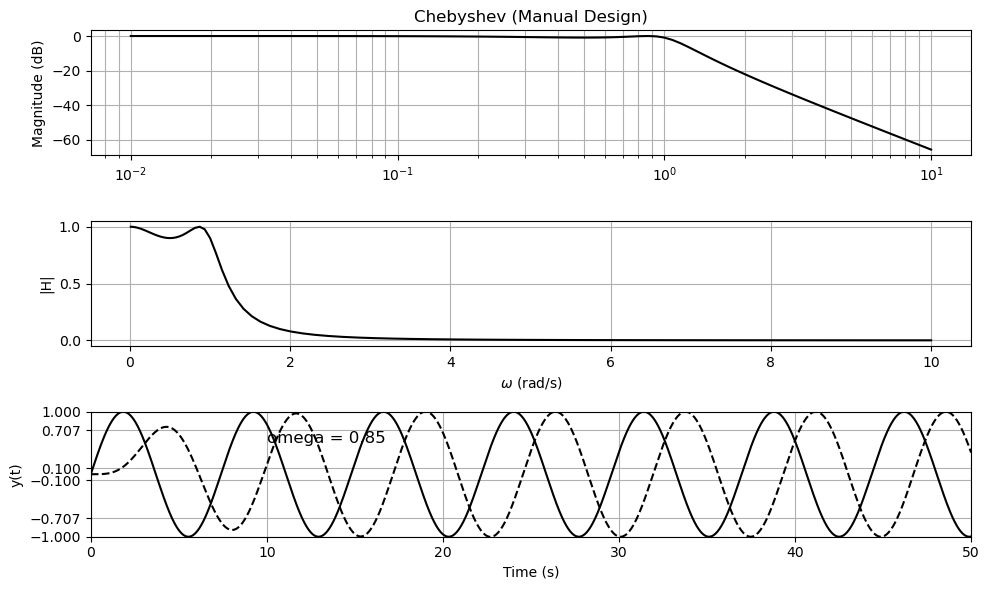

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt, log10

Hp = .9
Hs = .1
ws = 2
eps = sqrt((1/Hp**2) - 1)

aa = np.arccosh((1/eps)*sqrt((1/Hs**2)-1))
bb = 1 / np.arccosh(ws)
n = aa * bb
print('n = ', n)

# Override for design test
n = 3

alpha = 1/eps + sqrt(1 + 1/eps**2)
print('alpha = ', alpha)

a = 0.5 * (alpha**(1/n) - alpha**(-1/n))
b = 0.5 * (alpha**(1/n) + alpha**(-1/n))
print('a = ', a, ' b = ', b)

theta = (180 - 60) * (pi/180)
d1 = [1, -2*a*cos(theta), (a**2)*cos(theta)**2 + (b**2)*sin(theta)**2]

d2 = [1, a]
K = d1[2] * a

num = [0, 0, K]
den = np.convolve(d1, d2)

system = sig.TransferFunction(num, den)
w, Hmag, Hphase = sig.bode(system)

plt.figure(figsize=(10, 6))
plt.subplot(311)
plt.semilogx(w, Hmag, 'k')
plt.title('Chebyshev (Manual Design)')
plt.ylabel('Magnitude (dB)')
plt.grid(which='both')

plt.subplot(312)
plt.plot(w,10**(0.05*Hmag),'k')
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H|')

# ---- Time-domain simulation ----
dt = 0.001
NN = 50000
TT = np.arange(0, NN*dt, dt)
y = np.zeros(NN)
f = np.zeros(NN)

A, B, C, D = sig.tf2ss(num, den)
x = np.zeros(np.shape(B))

omega = 0.85
for n in range(NN):
    f[n] = sin(omega * n * dt)

plt.subplot(313)
plt.plot(TT, f, 'k')
plt.yticks([-1, 0, 1])
plt.axis([0, NN*dt, -1, 1])
plt.grid()
plt.ylabel('f(t)')

for m in range(NN):
    x = x + dt*A.dot(x) + dt*B*f[m]
    y[m] = C.dot(x) + D*f[m]

plt.plot(TT, y, 'k--')
plt.yticks([-1, -0.707, -0.1, 0.1, 0.707, 1])
plt.text(10, 0.5, f'omega = {round(omega, 2)}', fontsize=12)
plt.xlabel('Time (s)')
plt.ylabel('y(t)')
plt.tight_layout()
plt.show()
